In [1]:
from pathlib import Path
import pathlib
temp = pathlib.PosixPath
pathlib.PosixPath = pathlib.WindowsPath

from fastai.vision.all import *
# from fastai.vision.all import load_learner
import numpy as np
from PIL import Image
from IPython.display import display

np.int = np.int32 # Need to add this to make preset model work

In [2]:
# The colorblind friendly version
def add_mask2(source: Image.Image, truth: np.ndarray, pred: np.ndarray) -> Image.Image:
    """
    Given source black and white image, true and predicted mask this function returns image
    with areas colored as following:
    - Blue - annotation only
    - Green - prediction only
    - Purple - overlap
    """
    # Convert the source image to RGBA mode
    source = source.convert('RGBA')

    # Create an empty mask with an additional alpha channel
    M = np.zeros((*truth.shape, 4), dtype=np.uint8)

    # Set the blue channel for true annotations, orange channel for predictions, and alpha channel for visibility
    M[:, :, 2] = truth[:, :] * 255  # Blue for truth
    M[:, :, 1] = pred[:, :] * 128   # Green for prediction
    M[:, :, 0] = (truth & pred) * 255  # Purple for overlap
    M[:, :, 3] = ((truth > 0) | (pred > 0)) * 75  # Alpha for transparency (75/255)

    # Create an RGBA mask from the numpy array
    mask = Image.fromarray(M, 'RGBA')

    # Overlay the mask on the source image
    return Image.alpha_composite(source, mask)
    
# # Original version
# def add_mask2(source: Image.Image, truth: np.ndarray, pred: np.ndarray) -> Image.Image:
#     """
#     Given source black and white image, true and predicted mask this function returns image
#     with areas colored as following:
#     - Green - annotation only
#     - Red - prediction only
#     - Yellow - overlap
#     """
#     source = source.convert('RGBA')
#     M = np.zeros((*truth.shape, 4), dtype=np.uint8)
#     M[:, :, 1] = truth[:, :] * 255
#     M[:, :, 0] = pred[:, :] * 255
#     M[:, :, 3] = ((truth > 0) | (pred > 0)) * 75
    
#     mask = Image.fromarray(M, 'RGBA')
#     return Image.alpha_composite(source, mask)

In [22]:
def image2segmentation_path(imgpath: Path) -> Path:
    return Path(str(imgpath).replace("images", "segmentations"))

def segmentation2image_path(imgpath: Path) -> Path:
    return Path(str(imgpath).replace("prosome\data\segmentations_processed","images_processed"))

def image2segmentation_path2(imgpath: Path) -> Path:
    return Path(str(imgpath).replace("images_processed","prosome\data\segmentations_processed"))

def segmentation2image_path_crop(imgpath: Path) -> Path:
    return Path(str(imgpath).replace("prosome\data\segmentations_processed","cropped_prosome_annotation\data\images_processed"))

def pixels2area(n: int) -> float:
    """Converts number of pixels into area in um^2"""
    return n * 0.023 * 0.023

def area2mass(A: float) -> float:
    """Converts area in um^2 into mass in mg"""
    return 0.197 * (A ** 1.38)

# For calculating the percent overlap of pixels between masks
def calculate_overlap(mask1, mask2):
    # Ensure the masks have the same shape
    if mask1.shape != mask2.shape:
        raise ValueError("Masks must have the same shape.")
    
    # Calculate the intersection and union
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    
    # Calculate the percentage overlap
    if union == 0:
        return 0.0  # Avoid division by zero if both masks are empty
    else:
        return (intersection / union) * 100

# For calculating the different model performance metrics
# Precision: TP/(TP+FP) (IoU)
# Recall/Sensitivity: TP/(TP+FN)
# F1 Score: (2xPrecisionxRecall)/(Precision+Recall)
# Specificity: TN/(TN+FP) (negative results/true negatives)... might not be useful for the blanks
def calculate_performance_metrics(mask1, mask2):
    # Ensure the masks have the same shape
    if mask1.shape != mask2.shape:
        raise ValueError("Masks must have the same shape.")
    
    # Calculate the intersection and area of annotated mask
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    mask1_area = np.sum(mask1)
    
    # Calculate the percentage overlap
    if mask1_area == 0:
        IoU = 0.0  # Avoid division by zero if both masks are empty
        Recall = 0.0 #  percent overlap of the prediction relative to the annotated mask
        F1score = 0.0
    else:
        IoU = (intersection / union) * 100
        Recall = (intersection / mask1_area) * 100
        F1Score = 2*(IoU*Recall)/(IoU+Recall)
        
    return IoU, Recall, F1Score


In [4]:
# TODO fix this section wherein the conditional batch norm needs to be read
import torch.nn as nn
# Function to modify BatchNorm layers
def modify_batchnorm(module):
    for child_name, child in module.named_children():
        if isinstance(child, nn.BatchNorm2d):
            # Replace BatchNorm2d with a conditional version or skip logic
            setattr(module, child_name, ConditionalBatchNorm(child.num_features))
        else:
            modify_batchnorm(child)

# Define a custom conditional batch normalization layer
class ConditionalBatchNorm(nn.Module):
    def __init__(self, num_features):
        super(ConditionalBatchNorm, self).__init__()
        self.bn = nn.BatchNorm2d(num_features)
    
    def forward(self, x):
        # Apply BatchNorm only if the spatial dimensions are greater than 1
        if x.size(2) > 1 and x.size(3) > 1:
            return self.bn(x)
        else:
            return x

# Other modules needed from training
class CombinedLoss:
    "Dice and Focal combined"
    def __init__(self, axis=1, smooth=1., alpha=1.):
        store_attr()
        self.focal_loss = FocalLossFlat(axis=axis)
        self.dice_loss =  DiceLoss(axis, smooth)
        
    def __call__(self, pred, targ):
        return self.focal_loss(pred, targ) + self.alpha * self.dice_loss(pred, targ)
    
    def decodes(self, x):    return x.argmax(dim=self.axis)
    def activation(self, x): return F.softmax(x, dim=self.axis)

def IoU(preds:Tensor, targs:Tensor, eps:float=1e-8):
    """Computes the Jaccard loss, a.k.a the IoU loss.
    Notes: [Batch size,Num classes,Height,Width]
    Args:
        targs: a tensor of shape [B, H, W] or [B, 1, H, W].
        preds: a tensor of shape [B, C, H, W]. Corresponds to
            the raw output or logits of the model. (prediction)
        eps: added to the denominator for numerical stability.
    Returns:
        iou: the average class intersection over union value 
             for multi-class image segmentation
    """
    num_classes = preds.shape[1]
    
    # Single class segmentation?
    if num_classes == 1:
        true_1_hot = torch.eye(num_classes + 1)[targs.squeeze(1)]
        true_1_hot = true_1_hot.permute(0, 3, 1, 2).float()
        true_1_hot_f = true_1_hot[:, 0:1, :, :]
        true_1_hot_s = true_1_hot[:, 1:2, :, :]
        true_1_hot = torch.cat([true_1_hot_s, true_1_hot_f], dim=1)
        pos_prob = torch.sigmoid(preds)
        neg_prob = 1 - pos_prob
        probas = torch.cat([pos_prob, neg_prob], dim=1)
        
    # Multi-class segmentation
    else:
        # Convert target to one-hot encoding
        # true_1_hot = torch.eye(num_classes)[torch.squeeze(targs,1)]
        true_1_hot = torch.eye(num_classes)[targs.squeeze(1)]
        
        # Permute [B,H,W,C] to [B,C,H,W]
        true_1_hot = true_1_hot.permute(0, 3, 1, 2).float()
        
        # Take softmax along class dimension; all class probs add to 1 (per pixel)
        probas = F.softmax(preds, dim=1)
        
    true_1_hot = true_1_hot.type(preds.type())
    
    # Sum probabilities by class and across batch images
    dims = (0,) + tuple(range(2, targs.ndimension()))
    intersection = torch.sum(probas * true_1_hot, dims) # [class0,class1,class2,...]
    cardinality = torch.sum(probas + true_1_hot, dims)  # [class0,class1,class2,...]
    union = cardinality - intersection
    iou = (intersection / (union + eps)).mean()   # find mean of class IoU values
    return iou

In [17]:
# model = load_learner("models/learner_down4_1015.pkl", cpu=True)  # File models/learner.pkl
# model.load("model_resnet34_1015")  # File models/model_resnet34.pth
# model.dls.device = 'cpu' # PP? Why is it ran with the cpu and not the gpu?

model = load_learner("models/learner_prosomeLOKI_20250328.pkl", cpu=True)
model.load("learner_prosomeLOKI_20250328")
model.dls.device = 'cpu'

In [30]:
# imgs = sorted(list(Path("images/example_inputs_orig").glob("*.bmp")))

# imgs = sorted(list(Path("../downscaled_4/data/images_processed").glob("*.bmp")))
# imgs = sorted(list(Path("images/example_inputs_lowres").glob("*.bmp")))
# imgs = sorted(list(Path("images/example_inputs_lowres2").glob("*.bmp")))

# The UVP images
# imgs = sorted(list(Path("../data_loki/data/images_processed").glob("*.bmp")))
# imgs = sorted(list(Path("../uvp_images/UVP6_darkedge_copepod_black_bg").glob("*.png")))
# imgs = sorted(list(Path("../uvp_images/UVP5_inverted_images").glob("*.jpg")))

# The LOKI images with prosome masks for the crop
imgs = sorted(list(Path("../data_loki/data/prosome/data/segmentations_processed").glob("*.bmp")))


# imgs = imgs[1:100]
# imgs[1:5]


..\data_loki\data\prosome\data\segmentations_processed\20130815 104202 761 000000 0103 0536.bmp


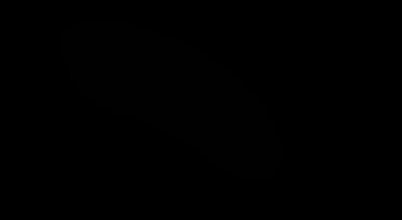

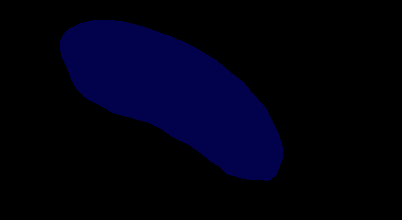

Percent overlap between masks: 0.00%
IoU: 0.00%
Recall: 0.00%
F1 score: nan%
Lipid annotation: 4.872 mg
Lipid prediction: 0.0 mg


C:\Users\patri\AppData\Local\Temp\ipykernel_10488\3857868768.py:60: RuntimeWarning: invalid value encountered in scalar divide
  F1Score = 2*(IoU*Recall)/(IoU+Recall)


In [29]:
#%%Skip
# Can delete this section
pimg = imgs[1]
im = Image.open(pimg)
p_segmentation = image2segmentation_path2(pimg)

print(p_segmentation)

# p_segmentation = image2segmentation_path2(pimg) # The lipid segmentations
# impath = segmentation2image_path(pimg) # The original images
# impathCropped = segmentation2image_path_crop(pimg) # The cropped prosomes
# im = Image.open(impath)

display(im)
# display(Image.open(p_segmentation))
# mask, *_ = model.predict(impathCropped)
mask, *_ = model.predict(pimg)
im_pred_mask = mask.numpy()
im_truth = np.array(Image.open(p_segmentation).convert("L"))

# print(im.shape)
# display(im_truth)
# print(im_truth.shape)

img_with_masks = add_mask2(im, im_truth, im_pred_mask)
display(img_with_masks.convert("RGB"))

# TODO get IoU

# Metrics
lipid_annotated = area2mass(pixels2area((im_truth > 0).sum()))
lipid_predicted = area2mass(pixels2area((im_pred_mask > 0.5).sum()))
percent_overlap = calculate_overlap(im_truth, im_pred_mask)
IoU, Recall, F1score = calculate_performance_metrics(im_truth, im_pred_mask)

print(f"Percent overlap between masks: {percent_overlap:.2f}%")
print(f"IoU: {IoU:.2f}%")
print(f"Recall: {Recall:.2f}%")
print(f"F1 score: {F1score:.2f}%")
print(f"Lipid annotation: {lipid_annotated:.5} mg")
print(f"Lipid prediction: {lipid_predicted:.5} mg")

In [31]:
# The version of the lipid annotation model for LOKI images with prosomes cropped out first
model = load_learner("models/learner_prosomeLOKI_20250328.pkl", cpu=True)
model.load("learner_prosomeLOKI_20250328")
model.dls.device = 'cpu'

# Initialize an empty list to store output data metrics
outdata = []

# Image directory
save_dir = "prediction_outputs/loki2013_prosome"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for pimg in imgs:
    # im = Image.open(pimg)
    # p_segmentation = image2segmentation_path(pimg)

    # For segmenting prosomes
    p_segmentation = pimg
    impath = segmentation2image_path(pimg) # The original images
    im = Image.open(impath)
    mask, *_ = model.predict(impath)
    im_pred_mask = mask.numpy()
    
    # For when the prosomes are cropped out first
    # p_segmentation = image2segmentation_path2(pimg) # The lipid segmentations
    # impath = segmentation2image_path(pimg) # The original images
    # # impathCropped = segmentation2image_path_crop(pimg) # The cropped prosomes
    # im = Image.open(impath)
    
    # Predict returns the decoded prediction, index of the predicted class, and tensor of probabilities (but here
    #  only the decoded prediction is retained/
    # mask, *_ = model.predict(impathCropped)
    # mask, *_ = model.predict(pimg)
    # im_pred_mask = mask.numpy()

    if p_segmentation is not None:
        im_truth = np.array(Image.open(p_segmentation).convert("L"))
    else:
        im_truth = np.zeros_like(im_pred_mask)

    # # if there are no true segmentation files at all:
    # im_truth = np.zeros_like(im_pred_mask)

    img_with_masks = add_mask2(im, im_truth, im_pred_mask)

    # Calculate metrics
    pixels_annotated = (im_truth > 0).sum()
    pixels_predicted = (im_pred_mask > 0.5).sum()
    lipid_annotated = area2mass(pixels2area(pixels_annotated))
    lipid_predicted = area2mass(pixels2area(pixels_predicted))
    IoU, Recall, F1score = calculate_performance_metrics(im_truth, im_pred_mask)
    # Blue - annotation
    # Green - prediction
    # Purple - overlap
    image_rgb = img_with_masks.convert("RGB")

    # # Display outputs in the chunk
    # print("************************")
    # print(pimg)
    # print(f"Lipid annotation: {lipid_annotated:.5}mg")
    # print(f"Lipid prediction: {lipid_predicted:.5}mg")
    # display(image_rgb)

    out_dir, out_fname = os.path.split(pimg) # Separate the directory from the file name
    filename_without_ext, ext = os.path.splitext(out_fname) # separate the extention
    updated_filename = f"{filename_without_ext}_overlapRGB{ext}"

    # Define the output path
    output_path = os.path.join(save_dir, updated_filename)
    image_rgb.save(output_path)
    
    
    outdata.append([out_dir, out_fname, pixels_annotated, pixels_predicted, 
                    IoU, Recall, F1score])

# Create and export the dataframe of output data
df = pd.DataFrame(outdata, 
                  columns = ['directory','filename','prosome_pixels_annotated','prosome_pixels_predicted',
                             'IoU','Recall', 'F1score'])

df.to_csv(os.path.join(save_dir,'prediction_results_prosome.csv'), index=False)

print("Prediction and output done")

C:\Users\patri\AppData\Local\Temp\ipykernel_10488\3857868768.py:60: RuntimeWarning: invalid value encountered in scalar divide
  F1Score = 2*(IoU*Recall)/(IoU+Recall)


Prediction and output done


In [ ]:
# The original version of the lipid annotation model for LOKI images used in the Maps et al. 2022 paper but applied to the reduced number of images
# model = load_learner("models/learner_orig.pkl", cpu=True)
# model.load("model_resnet34_orig")
# model.dls.device = 'cpu'


# Initialize an empty list to store output data metrics
outdata = []

# Image directory
save_dir = "prediction_outputs/uvp6_lokidownscale4"

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for pimg in imgs:
    im = Image.open(pimg)
    p_segmentation = image2segmentation_path(pimg)

    # # For when the prosomes are cropped out first
    # p_segmentation = image2segmentation_path2(pimg) # The lipid segmentations
    # impath = segmentation2image_path(pimg) # The original images
    # impathCropped = segmentation2image_path_crop(pimg) # The cropped prosomes
    # im = Image.open(impath)
    # mask, *_ = model.predict(impathCropped)
    
    # Predict returns the decoded prediction, index of the predicted class, and tensor of probabilities (but here
    #  only the decoded prediction is retained/
    mask, *_ = model.predict(pimg)
    im_pred_mask = mask.numpy()

    if p_segmentation is not None:
        im_truth = np.array(Image.open(p_segmentation).convert("L"))
    else:
        im_truth = np.zeros_like(im_pred_mask)

    # # if there are no true segmentation files at all:
    # im_truth = np.zeros_like(im_pred_mask)

    img_with_masks = add_mask2(im, im_truth, im_pred_mask)

    # Calculate metrics
    pixels_annotated = (im_truth > 0).sum()
    pixels_predicted = (im_pred_mask > 0.5).sum()
    lipid_annotated = area2mass(pixels2area(pixels_annotated))
    lipid_predicted = area2mass(pixels2area(pixels_predicted))
    IoU, Recall, F1score = calculate_performance_metrics(im_truth, im_pred_mask)
    
    # Blue - annotation
    # Green - prediction
    # Purple - overlap
    image_rgb = img_with_masks.convert("RGB")

    # # Display outputs in the chunk
    # print("************************")
    # print(pimg)
    # print(f"Lipid annotation: {lipid_annotated:.5}mg")
    # print(f"Lipid prediction: {lipid_predicted:.5}mg")
    # display(image_rgb)

    out_dir, out_fname = os.path.split(pimg) # Separate the directory from the file name
    filename_without_ext, ext = os.path.splitext(out_fname) # separate the extention
    updated_filename = f"{filename_without_ext}_overlapRGB{ext}"

    # Define the output path
    output_path = os.path.join(save_dir, updated_filename)
    image_rgb.save(output_path)
    
    
    outdata.append([out_dir, out_fname, pixels_annotated, pixels_predicted, 
                    lipid_annotated, lipid_predicted, IoU, Recall, F1score ])

# Create and export the dataframe of output data
df = pd.DataFrame(outdata, 
                  columns = ['directory','filename','lipid_pixels_annotated','lipid_pixels_predicted',
                             'lipid_mass_annotated','lipid_mass_predicted','IoU','Recall', 'F1score'])

df.to_csv(os.path.join(save_dir,'prediction_results.csv'), index=False)

print("Prediction and output done")

In [ ]:
# TODO Add some segmentation diagnostics and output the images


# In a table, output: metadata, IoU,  lipid_annotated, lipid_predicted, ... as pixels, area, and mass

# Export image_with_masks.convert("RGB") to a folder for images with both annotation and prediction